# sPHENIX TPC: direct Green-function convolution

This notebook follows the electrostatic calculation in the literal computational order

$$
G(x,x')
\;\longrightarrow\;
\text{QA of }G
\;\longrightarrow\;
\rho(x')
\;\longrightarrow\;
\Phi(x)
\;\longrightarrow\;
\mathbf E(x).
$$

Here

$$
x=(r,\phi,z)
$$

is the observation point and

$$
x'=(r',\phi',z')
$$

is the source point.

The essential difference from the faster modal notebook is that this notebook first constructs and stores the sampled six-coordinate kernels

$$
G(r,\phi,z;r',\phi',z'),
$$

$$
K_r=-\frac{\partial G}{\partial r},
\qquad
K_\phi=-\frac{1}{r}\frac{\partial G}{\partial\phi},
\qquad
K_z=-\frac{\partial G}{\partial z},
$$

and then uses those exact stored arrays in the discrete convolution.

The Green arrays are therefore not only diagnostic output. They are the numerical objects from which the potential and electric field are calculated.

By default the source is axisymmetric, all azimuthal modulation amplitudes are zero, and only the $m=0$ Fourier mode is retained automatically. Optional $\phi$ modulation is supported. Default QA is shown only in the $r$-$z$ plane.

## 1. Electrostatic equations

The perturbing potential produced by the positive-ion cloud satisfies

$$
\nabla^2\Phi(x)
=
-\frac{\rho(x)}{\epsilon_0}.
$$

The electric field is

$$
\mathbf E(x)
=
-\nabla\Phi(x).
$$

The TPC half-volume is modeled as a grounded coaxial cavity,

$$
a<r<b,
\qquad
0<z<L,
\qquad
0\leq\phi<2\pi.
$$

The perturbing potential obeys

$$
\Phi(a,\phi,z)=\Phi(b,\phi,z)=0,
$$

$$
\Phi(r,\phi,0)=\Phi(r,\phi,L)=0.
$$

For sPHENIX we use

$$
a=20\ \mathrm{cm},
\qquad
b=75.911\ \mathrm{cm},
\qquad
L=102.325\ \mathrm{cm}.
$$

The ion source begins near $r=30\ \mathrm{cm}$, but this is only a source edge. The physical inner electrostatic boundary remains at $r=20\ \mathrm{cm}$.

## 2. Green function

The Green function satisfies

$$
-\nabla_x^2G(x,x')
=
\frac{
\delta(r-r')
\delta(\phi-\phi')
\delta(z-z')
}{r},
$$

with the same grounded boundaries as the potential.

Once it is known,

$$
\Phi(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')G(x,x'),
$$

where

$$
dV'
=
r'\,dr'\,d\phi'\,dz'.
$$

The field is obtained from differentiated kernels,

$$
E_r(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_r(x,x'),
$$

$$
E_\phi(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_\phi(x,x'),
$$

$$
E_z(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_z(x,x').
$$

This notebook evaluates the direct finite-cavity Fourier--Bessel--sine representation

$$
G(r,r',z,z',\phi,\phi')
=
\sum_{m=0}^{m_{\max}}
\sum_{n=1}^{N_r}
\sum_{l=1}^{N_z}
\frac{2-\delta_{m0}}{2\pi}
\cos[m(\phi-\phi')]
\frac{R_{mn}(r)R_{mn}(r')}{N_{mn}^2}
\frac{2}{L}
\frac{\sin(q_lz)\sin(q_lz')}
{k_{mn}^2+q_l^2}.
$$

This exact triple-sum form is a direct separation-of-variables solution of the finite grounded cavity. It is not claimed to be a verbatim displayed equation from Rossegger's thesis, but it solves the same Dirichlet boundary-value problem in the complete-mode limit.

In [1]:
import json, time
from pathlib import Path
from array import array

import numpy as np
import ROOT as root
from scipy import optimize, special
from numpy.polynomial.legendre import leggauss
from IPython.display import display, Image

root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetNumberContours(80)

EPSILON_0 = 8.8541878128e-12
CM_TO_M = 1e-2
M_TO_CM = 100.0

Welcome to JupyROOT 6.30/06


In [2]:
# Geometry
A_CM, B_CM, L_CM = 20.0, 75.911, 102.325
SOURCE_R_MIN_CM, SOURCE_R_MAX_CM = 20.01, 75.911

# Charge model
RHO_REFERENCE_NC_PER_M3 = 20.0
K_EFF = 1.0
RADIAL_POWER_ALPHA = 1.0
M1_AMPLITUDE, M1_PHASE = 0.0, 0.0
M12_AMPLITUDE, M12_PHASE = 0.0, 0.0

# Direct Green grids: moderate defaults to control memory
NR_OBS, NPHI_OBS, NZ_OBS = 10, 10, 14
NR_SRC, NPHI_SRC, NZ_SRC = 9, 10, 11

# Modal truncation
M_PHI_MAX = 4
N_RADIAL_MODES = 14
N_LONGITUDINAL_MODES = 16
AUTO_AXISYMMETRIC = True

# QA
DO_QA = True
DO_PHI_QA = False
DO_GAUSS_QA = True

# Outputs
GREEN_FILE = "sphenix_direct_green_kernels.root"
FIELD_FILE = "sphenix_direct_fields_3d.root"
GARFIELD_FILE = "sphenix_direct_garfield_field.root"
QA_DIR = Path("direct_green_qa")
QA_DIR.mkdir(exist_ok=True)

## 3. Discrete source and observation grids

The Green function has six coordinates. On a grid it becomes

$$
G[i_r,i_\phi,i_z,j_r,j_\phi,j_z].
$$

The first three indices label observation points and the last three label source points.

If

$$
N_{\rm obs}
=
N_r^{\rm obs}N_\phi^{\rm obs}N_z^{\rm obs}
$$

and

$$
N_{\rm src}
=
N_r^{\rm src}N_\phi^{\rm src}N_z^{\rm src},
$$

then each dense kernel contains

$$
N_{\rm obs}N_{\rm src}
$$

floating-point values.

We store four arrays: $G$, $K_r$, $K_\phi$, and $K_z$. The notebook prints the memory estimate before constructing them.

In [3]:
a, b, L = A_CM*CM_TO_M, B_CM*CM_TO_M, L_CM*CM_TO_M
rs0, rs1 = SOURCE_R_MIN_CM*CM_TO_M, SOURCE_R_MAX_CM*CM_TO_M

phi_uniform = abs(M1_AMPLITUDE) < 1e-15 and abs(M12_AMPLITUDE) < 1e-15
M_EFFECTIVE = 0 if AUTO_AXISYMMETRIC and phi_uniform else M_PHI_MAX

r_obs_edges = np.linspace(a, b, NR_OBS+1)
phi_obs_edges = np.linspace(0, 2*np.pi, NPHI_OBS+1)
z_obs_edges = np.linspace(0, L, NZ_OBS+1)
r_obs = 0.5*(r_obs_edges[:-1]+r_obs_edges[1:])
phi_obs = 0.5*(phi_obs_edges[:-1]+phi_obs_edges[1:])
z_obs = 0.5*(z_obs_edges[:-1]+z_obs_edges[1:])

r_src_edges = np.linspace(rs0, rs1, NR_SRC+1)
phi_src_edges = np.linspace(0, 2*np.pi, NPHI_SRC+1)
z_src_edges = np.linspace(0, L, NZ_SRC+1)
r_src = 0.5*(r_src_edges[:-1]+r_src_edges[1:])
phi_src = 0.5*(phi_src_edges[:-1]+phi_src_edges[1:])
z_src = 0.5*(z_src_edges[:-1]+z_src_edges[1:])

dV = (
    0.5*(r_src_edges[1:]**2-r_src_edges[:-1]**2)[:,None,None]
    * np.diff(phi_src_edges)[None,:,None]
    * np.diff(z_src_edges)[None,None,:]
)

NOBS = NR_OBS*NPHI_OBS*NZ_OBS
NSRC = NR_SRC*NPHI_SRC*NZ_SRC
mem = NOBS*NSRC*8/1024**2

print("Observation points:", NOBS)
print("Source points:", NSRC)
print("Memory per kernel:", mem, "MiB")
print("Four-kernel memory:", 4*mem, "MiB")
print("Effective m_max:", M_EFFECTIVE)

Observation points: 1400
Source points: 990
Memory per kernel: 10.5743408203125 MiB
Four-kernel memory: 42.29736328125 MiB
Effective m_max: 0


## 4. Radial eigenfunctions and allowed radial wave numbers

For a fixed azimuthal order $m$, the radial equation has Bessel solutions. We define

$$
R_m(k,r)
=
J_m(kr)Y_m(ka)
-
Y_m(kr)J_m(ka).
$$

This automatically gives

$$
R_m(k,a)=0.
$$

To make the same mode vanish at the outer field cage, we require

$$
R_m(k,b)=0.
$$

Therefore the allowed values of $k$ are roots of

$$
F_m(k)
=
J_m(kb)Y_m(ka)
-
Y_m(kb)J_m(ka).
$$

The roots are labeled $k_{mn}$, where $n$ counts radial modes. The normalization is

$$
N_{mn}^2
=
\int_a^b rR_{mn}^2(r)\,dr.
$$

In [4]:
def F(k,m):
    return special.jv(m,k*b)*special.yv(m,k*a)-special.yv(m,k*b)*special.jv(m,k*a)

def R(k,m,r):
    return special.jv(m,k*r)*special.yv(m,k*a)-special.yv(m,k*r)*special.jv(m,k*a)

def dR(k,m,r):
    return k*(special.jvp(m,k*r,1)*special.yv(m,k*a)-special.yvp(m,k*r,1)*special.jv(m,k*a))

def roots_for_m(m,nroot):
    roots=[]
    step=0.2*np.pi/(b-a)
    x=max(1e-6,0.1*np.pi/(b-a))
    fx=F(x,m)
    xmax=(nroot+m+25)*np.pi/(b-a)
    while x+step <= xmax and len(roots)<nroot:
        y=x+step
        fy=F(y,m)
        if np.isfinite(fx) and np.isfinite(fy) and fx*fy<0:
            rt=optimize.brentq(F,x,y,args=(m,),xtol=1e-13,rtol=1e-13)
            if not roots or abs(rt-roots[-1])>1e-9:
                roots.append(rt)
        x,fx=y,fy
    if len(roots)!=nroot:
        raise RuntimeError(f"m={m}: found {len(roots)} roots, requested {nroot}")
    return np.array(roots)

xg,wg=leggauss(160)
rr=0.5*(b-a)*xg+0.5*(b+a)
jac=0.5*(b-a)

k_modes={}
norms={}
for m in range(M_EFFECTIVE+1):
    k_modes[m]=roots_for_m(m,N_RADIAL_MODES)
    norms[m]=np.array([jac*np.sum(wg*rr*R(k,m,rr)**2) for k in k_modes[m]])
    print(m, max(abs(R(k,m,a)) for k in k_modes[m]), max(abs(R(k,m,b)) for k in k_modes[m]))

q_modes=np.arange(1,N_LONGITUDINAL_MODES+1)*np.pi/L

0 0.0 1.499494972634352e-14


## 5. Constructing the full Green-function and field-kernel arrays

This cell constructs four six-dimensional arrays:

$$
G(r,\phi,z;\,r',\phi',z'),
$$

$$
K_r(r,\phi,z;\,r',\phi',z'),
$$

$$
K_\phi(r,\phi,z;\,r',\phi',z'),
$$

and

$$
K_z(r,\phi,z;\,r',\phi',z').
$$

The first three coordinates,

$$
(r,\phi,z),
$$

describe the **observation point**, where the potential or electric field is evaluated.

The last three coordinates,

$$
(r',\phi',z'),
$$

describe the **source point**, where the charge is located.

All four arrays have the common shape

```python
shape = (
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
    NR_SRC,
    NPHI_SRC,
    NZ_SRC
)
```

The axis ordering is

```text
observation r,
observation phi,
observation z,
source r,
source phi,
source z
```

or, using compact index labels,

```text
R P Z S T U
```

where:

- `R` labels the observation radius $r$;
- `P` labels the observation angle $\phi$;
- `Z` labels the observation coordinate $z$;
- `S` labels the source radius $r'$;
- `T` labels the source angle $\phi'$;
- `U` labels the source coordinate $z'$.

For example,

```python
G[ir, ip, iz, jr, jp, jz]
```

is the Green-function value connecting the source point

$$
(r'_{jr},\phi'_{jp},z'_{jz})
$$

to the observation point

$$
(r_{ir},\phi_{ip},z_{iz}).
$$

### 5.1 Allocating the kernel arrays

The code begins by defining the common six-dimensional array shape:

```python
shape = (
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
    NR_SRC,
    NPHI_SRC,
    NZ_SRC
)
```

The Green-function and electric-field kernel arrays are then initialized:

```python
G  = np.zeros(shape)
Kr = np.zeros(shape)
Kp = np.zeros(shape)
Kz = np.zeros(shape)
```

Initially, every array element is zero.

The arrays are filled by summing the contributions from all retained modes:

$$
m=0,\ldots,m_{\max},
$$

$$
n=1,\ldots,N_{\mathrm{radial}},
$$

and

$$
\ell=1,\ldots,N_{\mathrm{longitudinal}}.
$$

The code uses `+=` because every mode contributes one term to the total Green function and field kernels.

Schematically,

$$
G
=
\sum_m
\sum_n
\sum_\ell
G_{mn\ell},
$$

and similarly for $K_r$, $K_\phi$, and $K_z$.

### 5.2 Angular difference between observation and source points

The angular part of the Green function depends on the difference

$$
\phi-\phi'.
$$

The code constructs all observation-source angular differences simultaneously:

```python
dphi = phi_obs[:, None] - phi_src[None, :]
```

Suppose

```python
phi_obs.shape == (NPHI_OBS,)
phi_src.shape == (NPHI_SRC,)
```

Then

```python
phi_obs[:, None].shape == (NPHI_OBS, 1)
phi_src[None, :].shape == (1, NPHI_SRC)
```

NumPy broadcasting produces

```python
dphi.shape == (NPHI_OBS, NPHI_SRC)
```

with elements

$$
(d\phi)_{PT}
=
\phi_P-\phi'_T.
$$

Thus, every observation angle $\phi_P$ is paired with every source angle $\phi'_T$.

The result is a two-dimensional matrix:

$$
d\phi
=
\begin{pmatrix}
\phi_0-\phi'_0 & \phi_0-\phi'_1 & \cdots \\
\phi_1-\phi'_0 & \phi_1-\phi'_1 & \cdots \\
\vdots & \vdots & \ddots
\end{pmatrix}.
$$

### 5.3 Loop over the azimuthal order m

The outer loop is

```python
for m in range(M_EFFECTIVE + 1):
```

For each azimuthal order $m$, the angular basis function is

$$
A_m(\phi,\phi')
=
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi-\phi')\right].
$$

The normalization factor is calculated as

```python
pref = (2.0 if m > 0 else 1.0) / (2*np.pi)
```

Therefore,

$$
\mathrm{pref}
=
\begin{cases}
\dfrac{1}{2\pi}, & m=0, \\[6pt]
\dfrac{1}{\pi}, & m>0.
\end{cases}
$$

The complete angular matrix is

```python
A = pref * np.cos(m*dphi)
```

with shape

```python
A.shape == (NPHI_OBS, NPHI_SRC)
```

and elements

$$
A_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi_P-\phi'_T)\right].
$$

For $m=0$, the angular factor is constant:

$$
A_0
=
\frac{1}{2\pi}.
$$

For $m>0$, the angular dependence oscillates with the relative angle $\phi-\phi'$.

### 5.4 Angular derivative for the Kphi kernel

The azimuthal electric-field kernel is defined as

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi}.
$$

The angular part of the Green function contains

$$
\cos\left[m(\phi-\phi')\right].
$$

Its negative derivative with respect to the observation angle $\phi$ is

$$
-\frac{\partial}{\partial\phi}
\cos\left[m(\phi-\phi')\right]
=
m\sin\left[m(\phi-\phi')\right].
$$

The code therefore constructs the differentiated angular matrix as

```python
Ap = (
    pref * m * np.sin(m*dphi)
    if m > 0
    else np.zeros_like(A)
)
```

Its elements are

$$
Ap_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
m\sin\left[m(\phi_P-\phi'_T)\right].
$$

For the axisymmetric mode $m=0$,

```python
Ap = np.zeros_like(A)
```

because

$$
\frac{\partial A_0}{\partial\phi}
=
0.
$$

Therefore, the $m=0$ mode gives no contribution to the azimuthal field kernel:

$$
K_\phi^{(m=0)}
=
0.
$$

### 5.5 Loop over the radial modes

The next loop is

```python
for n, k in enumerate(k_modes[m]):
```

Here:

- `n` is the radial-mode index;
- `k` is the corresponding radial eigenvalue $k_{mn}$.

For each radial mode, the radial basis function is evaluated at all observation radii:

```python
ro = R(k, m, r_obs)
```

This array represents

$$
R_{mn}(r).
$$

The radial derivative is evaluated as

```python
dro = dR(k, m, r_obs)
```

and represents

$$
R'_{mn}(r)
=
\frac{\partial R_{mn}(r)}{\partial r}.
$$

The radial basis function is also evaluated at all source radii:

```python
rs = R(k, m, r_src)
```

which represents

$$
R_{mn}(r').
$$

The array shapes are

```python
ro.shape  == (NR_OBS,)
dro.shape == (NR_OBS,)
rs.shape  == (NR_SRC,)
```

Thus, `ro` and `dro` depend only on the observation radius, while `rs` depends only on the source radius.

### 5.6 Radial observation-source matrices

The radial contribution to the scalar Green function is constructed as

```python
RG = np.outer(ro, rs) / norms[m][n]
```

The operation

```python
np.outer(ro, rs)
```

creates every observation-source product

$$
R_{mn}(r_R)\,R_{mn}(r'_S).
$$

Therefore,

```python
RG.shape == (NR_OBS, NR_SRC)
```

and its elements are

$$
RG_{RS}
=
\frac{
R_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

Here,

```python
norms[m][n]
```

contains the radial normalization

$$
N_{mn}^{2}
=
\int_a^b
r\,R_{mn}^{2}(r)\,dr.
$$

The radial factor for the radial electric-field kernel is

```python
RR = -np.outer(dro, rs) / norms[m][n]
```

with elements

$$
RR_{RS}
=
-
\frac{
R'_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

The minus sign appears because the radial field kernel is defined as

$$
K_r
=
-\frac{\partial G}{\partial r}.
$$

### 5.7 Loop over the longitudinal modes

The innermost loop is

```python
for q in q_modes:
```

The longitudinal wave numbers are

$$
q_\ell
=
\frac{\ell\pi}{L}.
$$

For each pair of radial and longitudinal modes, the denominator is

```python
den = k*k + q*q
```

which represents the Laplacian eigenvalue

$$
\lambda_{mn\ell}
=
k_{mn}^{2}
+
q_\ell^{2}.
$$

The longitudinal Green-function matrix is constructed as

```python
Z = (
    (2/L)
    * np.outer(
        np.sin(q*z_obs),
        np.sin(q*z_src)
    )
    / den
)
```

Its elements are

$$
Z_{ZU}
=
\frac{2}{L}
\frac{
\sin(q_\ell z_Z)\,
\sin(q_\ell z'_U)
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

The matrix shape is

```python
Z.shape == (NZ_OBS, NZ_SRC)
```

so `Z` connects every observation coordinate $z_Z$ to every source coordinate $z'_U$.

### 5.8 Longitudinal derivative for the Kz kernel

The longitudinal electric-field kernel is defined as

$$
K_z
=
-\frac{\partial G}{\partial z}.
$$

Using

$$
\frac{\partial}{\partial z}
\sin(q_\ell z)
=
q_\ell\cos(q_\ell z),
$$

we obtain

$$
-\frac{\partial}{\partial z}
\left[
\frac{2}{L}
\frac{
\sin(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}
\right]
=
-\frac{2}{L}
\frac{
q_\ell\cos(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

The code evaluates this expression as

```python
ZZ = (
    -(2/L)
    * np.outer(
        q*np.cos(q*z_obs),
        np.sin(q*z_src)
    )
    / den
)
```

The shape is

```python
ZZ.shape == (NZ_OBS, NZ_SRC)
```

The matrix `ZZ` therefore contains the observation-side longitudinal derivative of `Z`.

### 5.9 Understanding np.einsum

The scalar Green function is accumulated using

```python
G += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

The input index labels are

```text
RS, PT, ZU
```

This means:

- `RG` has indices `R,S`;
- `A` has indices `P,T`;
- `Z` has indices `Z,U`.

The output ordering is

```text
RPZSTU
```

Therefore, NumPy constructs a six-dimensional array with elements

$$
\mathrm{output}_{RPZSTU}
=
RG_{RS}\,
A_{PT}\,
Z_{ZU}.
$$

The indices correspond to

```text
R : observation radius
P : observation azimuth
Z : observation longitudinal coordinate
S : source radius
T : source azimuth
U : source longitudinal coordinate
```

Thus,

```python
np.einsum("RS,PT,ZU->RPZSTU", RG, A, Z)
```

constructs

$$
RG(r,r')\,
A(\phi,\phi')\,
Z(z,z')
$$

for every combination of

$$
(r,\phi,z,r',\phi',z').
$$

### 5.10 Why this einsum does not perform a summation

In Einstein summation notation, an index is summed over when it appears in the inputs but is absent from the output.

Here, the index structure is

```text
RS, PT, ZU -> RPZSTU
```

Every input index also appears in the output.

Therefore, this `einsum` does not sum over any array index.

Instead, it constructs the multidimensional outer product

$$
(R,S)
\otimes
(P,T)
\otimes
(Z,U).
$$

The modal summation is performed by the Python loops

```python
for m ...
    for n ...
        for q ...
```

and by the accumulation operation

```python
G += ...
```

Thus:

- `np.einsum` constructs one complete six-dimensional mode contribution;
- `+=` accumulates the contributions from all modes.

### 5.11 Small example of the same einsum operation

Suppose the input arrays have shapes

```python
RG.shape == (2, 3)
A.shape  == (4, 5)
Z.shape  == (6, 7)
```

Then

```python
out = np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z
)
```

has shape

```python
out.shape == (2, 4, 6, 3, 5, 7)
```

For example,

```python
out[1, 2, 4, 0, 3, 6]
```

is equal to

```python
RG[1, 0] * A[2, 3] * Z[4, 6]
```

In the Green-function calculation, this corresponds to

$$
G(r_1,\phi_2,z_4;\,r'_0,\phi'_3,z'_6).
$$

This element receives the product of:

- the radial response between $r_1$ and $r'_0$;
- the angular response between $\phi_2$ and $\phi'_3$;
- the longitudinal response between $z_4$ and $z'_6$.

### 5.12 Constructing the scalar Green function

The scalar Green function is accumulated using

```python
G += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

For one mode combination $(m,n,\ell)$, this adds

$$
\frac{
R_{mn}(r)\,R_{mn}(r')
}{
N_{mn}^{2}
}
\,
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi-\phi')\right]
\,
\frac{2}{L}
\frac{
\sin(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

After all loops are complete,

$$
G(r,\phi,z;\,r',\phi',z')
=
\sum_m
\sum_n
\sum_\ell
G_{mn\ell}(r,\phi,z;\,r',\phi',z').
$$

The resulting array contains the scalar response between every sampled source point and every sampled observation point.

### 5.13 Constructing the radial field kernel

The radial field kernel is accumulated using

```python
Kr += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RR,
    A,
    Z,
    optimize=True
)
```

The matrix `RR` contains the observation-side radial derivative:

$$
RR_{RS}
=
-
\frac{
R'_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

Therefore,

$$
K_r(r,\phi,z;\,r',\phi',z')
=
-\sum_{m,n,\ell}
\frac{
R'_{mn}(r)\,R_{mn}(r')
}{
N_{mn}^{2}
}
A_m(\phi,\phi')
Z_{mn\ell}(z,z').
$$

The angular and longitudinal factors are unchanged, while the radial basis at the observation point is differentiated.

This implements

$$
K_r
=
-\frac{\partial G}{\partial r}.
$$

### 5.14 Constructing the azimuthal field kernel

The azimuthal field kernel is accumulated using

```python
Kp += np.einsum(
    "R,RS,PT,ZU->RPZSTU",
    1/r_obs,
    RG,
    Ap,
    Z,
    optimize=True
)
```

The input index labels have the following meaning:

```text
R   : inverse observation radius, 1/r
RS  : radial observation-source matrix
PT  : differentiated angular matrix
ZU  : longitudinal observation-source matrix
```

The resulting elements are

$$
(K_\phi)_{RPZSTU}
=
\frac{1}{r_R}
RG_{RS}\,
Ap_{PT}\,
Z_{ZU}.
$$

The differentiated angular matrix is

$$
Ap_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
m\sin\left[m(\phi_P-\phi'_T)\right].
$$

This implements

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi}.
$$

For the axisymmetric mode $m=0$,

```python
Ap = 0
```

so the corresponding contribution to $K_\phi$ is zero.

### 5.15 Constructing the longitudinal field kernel

The longitudinal field kernel is accumulated using

```python
Kz += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    ZZ,
    optimize=True
)
```

This operation is identical to the scalar Green-function construction, except that the longitudinal matrix `Z` is replaced by its derivative `ZZ`.

The differentiated longitudinal matrix is

$$
ZZ_{ZU}
=
-\frac{2}{L}
\frac{
q_\ell\cos(q_\ell z_Z)\sin(q_\ell z'_U)
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

Therefore,

$$
K_z(r,\phi,z;\,r',\phi',z')
=
-\frac{\partial G}{\partial z}.
$$

Only the observation-side longitudinal basis is differentiated.

### 5.16 Role of optimize=True

Each `einsum` call includes

```python
optimize=True
```

This option asks NumPy to choose an efficient internal evaluation strategy.

For example,

```python
np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

contains no contracted indices, so mathematically it is a multidimensional outer product.

The `optimize=True` option may improve the order of internal operations and memory handling, but it does not change the result.

### 5.17 Interpretation of one loop iteration

For one specific mode combination

$$
(m,n,\ell),
$$

the code performs the following steps:

1. evaluates the angular response for all $(\phi,\phi')$ pairs;
2. evaluates the radial response for all $(r,r')$ pairs;
3. evaluates the longitudinal response for all $(z,z')$ pairs;
4. evaluates the radial, azimuthal, and longitudinal derivatives;
5. constructs the complete six-dimensional source-response contribution;
6. adds this contribution to the total arrays.

The nested loops implement the modal sum

$$
\sum_m
\sum_n
\sum_\ell.
$$

The `einsum` operation constructs the six-coordinate contribution associated with one term in this sum.

Schematically,

$$
\text{one mode}
\longrightarrow
\text{radial factor}
\times
\text{angular factor}
\times
\text{longitudinal factor}
\longrightarrow
\text{six-dimensional contribution}.
$$

### 5.18 Arrays available after this cell

After all modal loops are complete,

```python
G
```

contains the scalar Green function

$$
G(r,\phi,z;\,r',\phi',z'),
$$

```python
Kr
```

contains the radial field kernel

$$
K_r
=
-\frac{\partial G}{\partial r},
$$

```python
Kp
```

contains the azimuthal field kernel

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi},
$$

and

```python
Kz
```

contains the longitudinal field kernel

$$
K_z
=
-\frac{\partial G}{\partial z}.
$$

At this stage, no charge-density distribution has been introduced.

The arrays describe the geometry response to a unit source placed at every sampled source position.

For a source voxel $j$, the charge is

$$
\Delta Q_j
=
\rho_j\,\Delta V_j.
$$

The electrostatic potential at observation point $i$ is then

$$
\Phi_i
=
\frac{1}{\epsilon_0}
\sum_j
G_{ij}\,\Delta Q_j.
$$

The electric-field components are

$$
E_{r,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{r,ij}\,\Delta Q_j,
$$

$$
E_{\phi,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{\phi,ij}\,\Delta Q_j,
$$

and

$$
E_{z,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{z,ij}\,\Delta Q_j.
$$

The complete calculation sequence is

$$
\text{mode functions}
\longrightarrow
G,\ K_r,\ K_\phi,\ K_z
\longrightarrow
\rho\,\Delta V
\longrightarrow
\Phi,\ E_r,\ E_\phi,\ E_z.
$$

In [5]:
shape=(NR_OBS,NPHI_OBS,NZ_OBS,NR_SRC,NPHI_SRC,NZ_SRC)
G=np.zeros(shape)
Kr=np.zeros(shape)
Kp=np.zeros(shape)
Kz=np.zeros(shape)

dphi=phi_obs[:,None]-phi_src[None,:]
t0=time.time()

for m in range(M_EFFECTIVE+1):
    pref=(2.0 if m>0 else 1.0)/(2*np.pi)
    A=pref*np.cos(m*dphi)
    Ap=pref*m*np.sin(m*dphi) if m>0 else np.zeros_like(A)

    for n,k in enumerate(k_modes[m]):
        ro=R(k,m,r_obs); dro=dR(k,m,r_obs); rs=R(k,m,r_src)
        RG=np.outer(ro,rs)/norms[m][n]
        RR=-np.outer(dro,rs)/norms[m][n]

        for q in q_modes:
            den=k*k+q*q
            Z=(2/L)*np.outer(np.sin(q*z_obs),np.sin(q*z_src))/den
            ZZ=-(2/L)*np.outer(q*np.cos(q*z_obs),np.sin(q*z_src))/den

            G += np.einsum("RS,PT,ZU->RPZSTU",RG,A,Z,optimize=True)
            Kr += np.einsum("RS,PT,ZU->RPZSTU",RR,A,Z,optimize=True)
            Kp += np.einsum("R,RS,PT,ZU->RPZSTU",1/r_obs,RG,Ap,Z,optimize=True)
            Kz += np.einsum("RS,PT,ZU->RPZSTU",RG,A,ZZ,optimize=True)

print("Kernel build time:",time.time()-t0,"s")
print("Kernel shape:",G.shape)

Kernel build time: 4.571155548095703 s
Kernel shape: (10, 10, 14, 9, 10, 11)



## 6. Green-function QA before introducing the source

Before applying a charge-density distribution, we test the geometry-only Green function and electric-field kernels.

These tests verify:

1. the boundary conditions;
2. electrostatic reciprocity;
3. the analytical derivatives used to construct the field kernels;
4. the spatial response to a fixed point source.

---


### 6.1 Boundary-condition test

The scalar Green function must vanish whenever the observation point lies on a grounded boundary:

$$
G(\mathbf{x},\mathbf{x}') = 0,
\qquad
\mathbf{x} \in \partial\Omega.
$$

For the cylindrical TPC geometry, this includes the radial boundaries

$$
r=a,
\qquad
r=b,
$$

and the longitudinal boundaries

$$
z=0,
\qquad
z=L.
$$

Numerically, we evaluate the maximum absolute Green-function value on each boundary:

```python
max_abs_G_rmin = np.max(np.abs(G_at_rmin))
max_abs_G_rmax = np.max(np.abs(G_at_rmax))
max_abs_G_zmin = np.max(np.abs(G_at_zmin))
max_abs_G_zmax = np.max(np.abs(G_at_zmax))
````

For a sufficiently converged modal expansion, all four values should be close to zero.

---



### 6.2 Reciprocity test

Electrostatic reciprocity requires

$$
G(\mathbf{x},\mathbf{x}') = G(\mathbf{x}',\mathbf{x}).
$$

In array notation, this corresponds to exchanging the observation and source coordinates:

$$
(r,\phi,z)
\longleftrightarrow
(r',\phi',z').
$$

For equal observation and source grids, the transposed Green-function array is

```python
G_reciprocal = np.transpose(G, (3, 4, 5, 0, 1, 2))
```

The reciprocity residual is then

```python
reciprocity_residual = G - G_reciprocal
```

A useful relative measure is

$$
\epsilon_{\mathrm{rec}}= \frac{
\max\left|G(\mathbf{x},\mathbf{x}') - G(\mathbf{x}',\mathbf{x})\right|
}{
\max\left|G(\mathbf{x},\mathbf{x}')\right|
}.
$$

Numerically:

```python
reciprocity_error = (
    np.max(np.abs(reciprocity_residual))
    / np.max(np.abs(G))
)
```

This quantity should decrease as more radial, azimuthal, and longitudinal modes are retained.

---



### 6.3 Derivative consistency test

The field kernels are defined by derivatives of the scalar Green function:

$$
K_r=-\frac{\partial G}{\partial r},
$$

$$
K_\phi= -\frac{1}{r}
\frac{\partial G}{\partial\phi},
$$

and

$$
K_z=-\frac{\partial G}{\partial z}.
$$

We compare the analytical kernel values with finite-difference derivatives of the pointwise scalar Green function.

For the radial derivative,

$$
K_r(r,\phi,z;\mathbf{x}')
\approx-\frac{
G(r+\Delta r,\phi,z;\mathbf{x}')-G(r-\Delta r,\phi,z;\mathbf{x}')
}{
2\Delta r
}.
$$

For the azimuthal derivative,

$$
K_\phi(r,\phi,z;\mathbf{x}')
\approx-\frac{1}{r}
\frac{
G(r,\phi+\Delta\phi,z;\mathbf{x}')-G(r,\phi-\Delta\phi,z;\mathbf{x}')
}{
2\Delta\phi
}.
$$

For the longitudinal derivative,

$$
K_z(r,\phi,z;\mathbf{x}')
\approx-\frac{
G(r,\phi,z+\Delta z;\mathbf{x}')-G(r,\phi,z-\Delta z;\mathbf{x}')
}{
2\Delta z
}.
$$

The analytical and finite-difference values should agree away from boundaries and away from the source singularity.

---



### 6.4 Point-source response maps

Fixing one source point,

$$
\mathbf{x}'=(r',\phi',z'),
$$

leaves a three-dimensional response over observation space:

$$
G(r,\phi,z;\mathbf{x}'),
$$

$$
K_r(r,\phi,z;\mathbf{x}'),
$$

$$
K_\phi(r,\phi,z;\mathbf{x}'),
$$

and

$$
K_z(r,\phi,z;\mathbf{x}').
$$

For the default axisymmetric configuration, the response is independent of the absolute azimuthal angle. We therefore display two-dimensional maps in the $r$-$z$ plane.

The main QA maps are:

* the scalar Green function $G$;
* the radial field kernel $K_r$;
* the longitudinal field kernel $K_z$.

For a source index

```python
jr_src = ...
jp_src = ...
jz_src = ...
```

the corresponding observation-space slices are

```python
G_map = G[:, :, :, jr_src, jp_src, jz_src]
Kr_map = Kr[:, :, :, jr_src, jp_src, jz_src]
Kz_map = Kz[:, :, :, jr_src, jp_src, jz_src]
```

For an axisymmetric result, one observation-angle slice can be selected:

```python
ip_obs = 0

G_rz = G_map[:, ip_obs, :]
Kr_rz = Kr_map[:, ip_obs, :]
Kz_rz = Kz_map[:, ip_obs, :]
```

These maps allow us to inspect:

* whether the response vanishes on grounded boundaries;
* whether the field points away from a positive source;
* whether the response is symmetric around the source position;
* whether numerical oscillations appear because of modal truncation.

For each azimuthal order $m$, the angular basis function is

$$
A_m(\phi,\phi')=\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi-\phi')\right].
$$

The normalization factor is calculated as

```python
pref = (2.0 if m > 0 else 1.0) / (2*np.pi)
```

Therefore,

$$
\mathrm{pref}=\begin{cases}
\dfrac{1}{2\pi}, & m=0, [6pt]
\dfrac{1}{\pi}, & m>0.
\end{cases}
$$

The complete angular matrix is

```python
A = pref * np.cos(m*dphi)
```

with shape

```python
A.shape == (NPHI_OBS, NPHI_SRC)
```

and elements

$$
A_{PT}=\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi_P-\phi'_T)\right].
$$


## 6. Green-function QA before the source is introduced

We now test the geometry-only kernels.

### Boundary condition

The scalar Green function must vanish when the observation point lies on a grounded boundary.

### Reciprocity

Electrostatic reciprocity requires

$$
G(x,x')=G(x',x).
$$

### Derivative check

The analytical $K_r$, $K_\phi$, and $K_z$ values are compared with finite differences of the pointwise scalar Green function.

### Visual source-response maps

Fixing one source point leaves a three-dimensional observation-space response. With default axisymmetry we display $r$-$z$ maps of $G$, $K_r$, and $K_z$.

In [6]:
def green_point(r,p,z,rp,pp,zp):
    g=kr=kp=kz=0.0
    for m in range(M_EFFECTIVE+1):
        pref=(2.0 if m>0 else 1.0)/(2*np.pi)
        c=np.cos(m*(p-pp)); s=np.sin(m*(p-pp))
        for n,k in enumerate(k_modes[m]):
            ro=R(k,m,r); dro=dR(k,m,r); rs=R(k,m,rp); norm=norms[m][n]
            for q in q_modes:
                den=k*k+q*q
                zz=(2/L)*np.sin(q*z)*np.sin(q*zp)/den
                common=pref*rs/norm
                g += common*ro*c*zz
                kr += -common*dro*c*zz
                if m>0: kp += common*ro*(m/r)*s*zz
                kz += -common*ro*c*(2/L)*q*np.cos(q*z)*np.sin(q*zp)/den
    return g,kr,kp,kz

src_test=(0.50,0.7,0.54)
for x in [(a,0.3,0.4),(b,0.3,0.4),(0.5,0.3,0.0),(0.5,0.3,L)]:
    print("boundary G =",green_point(*x,*src_test)[0])

x1=(0.35,0.2,0.25); x2=(0.62,1.3,0.78)
g12=green_point(*x1,*x2)[0]; g21=green_point(*x2,*x1)[0]
print("reciprocity residual =",abs(g12-g21)/max(abs(g12),abs(g21),1e-30))

boundary G = 0.0
boundary G = 3.2637397731520697e-17
boundary G = 0.0
boundary G = -2.8576126027680423e-17
reciprocity residual = 4.98949007868199e-16


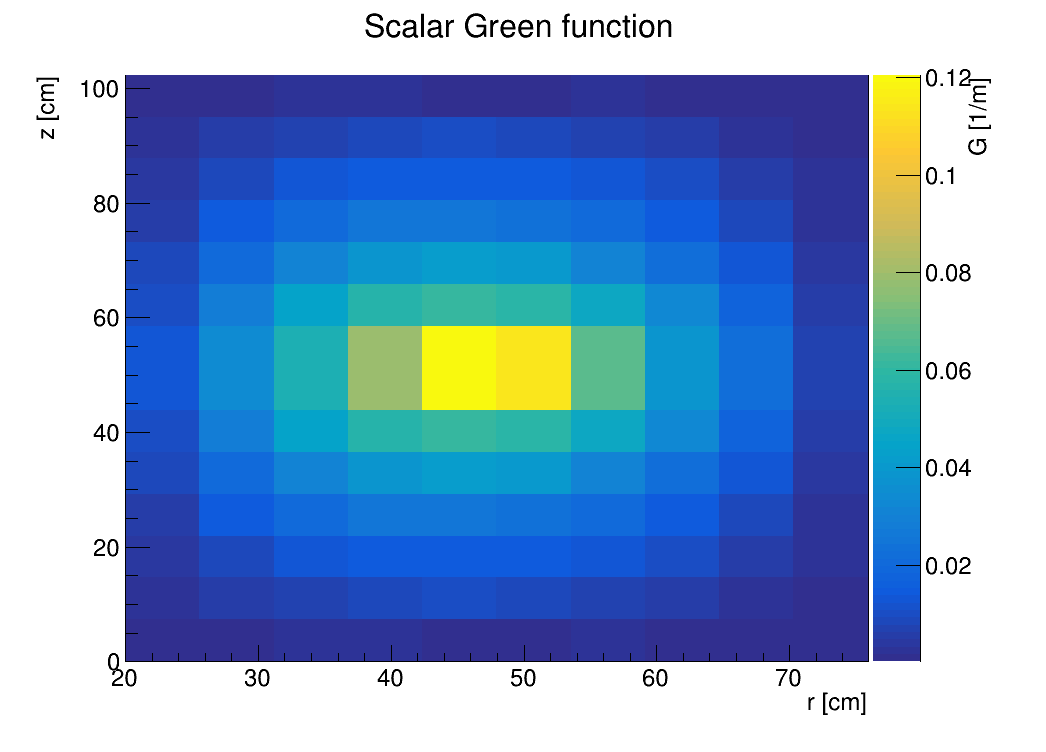

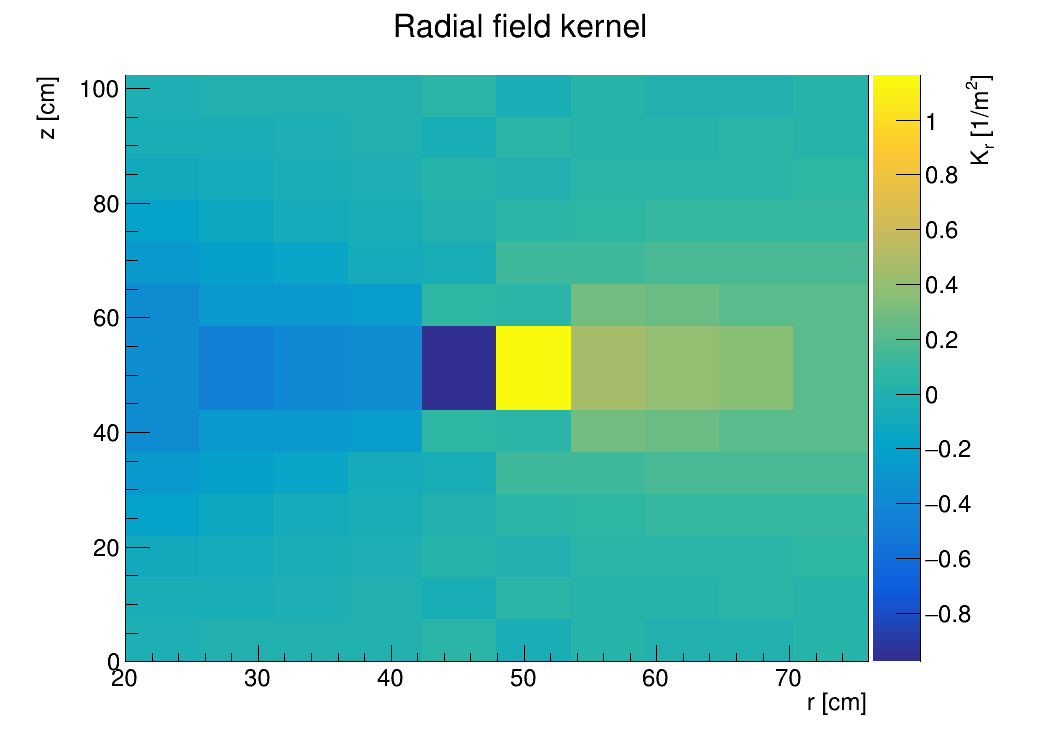

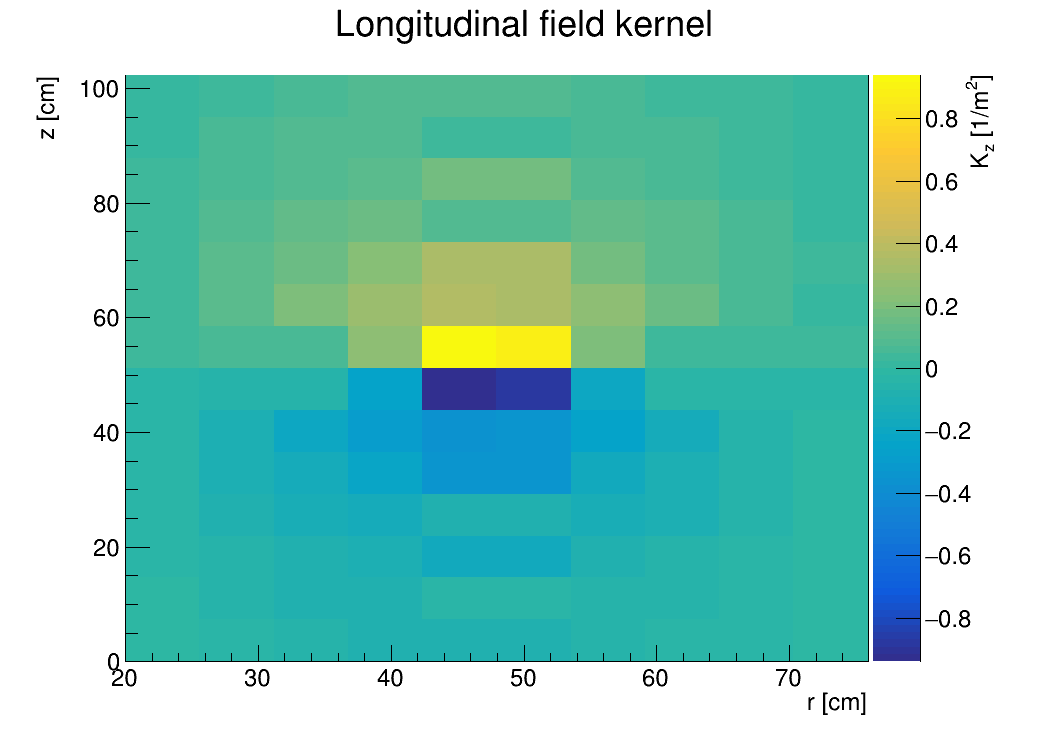

Info in <TCanvas::Print>: png file direct_green_qa/green_G.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/green_Kr.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/green_Kz.png has been created


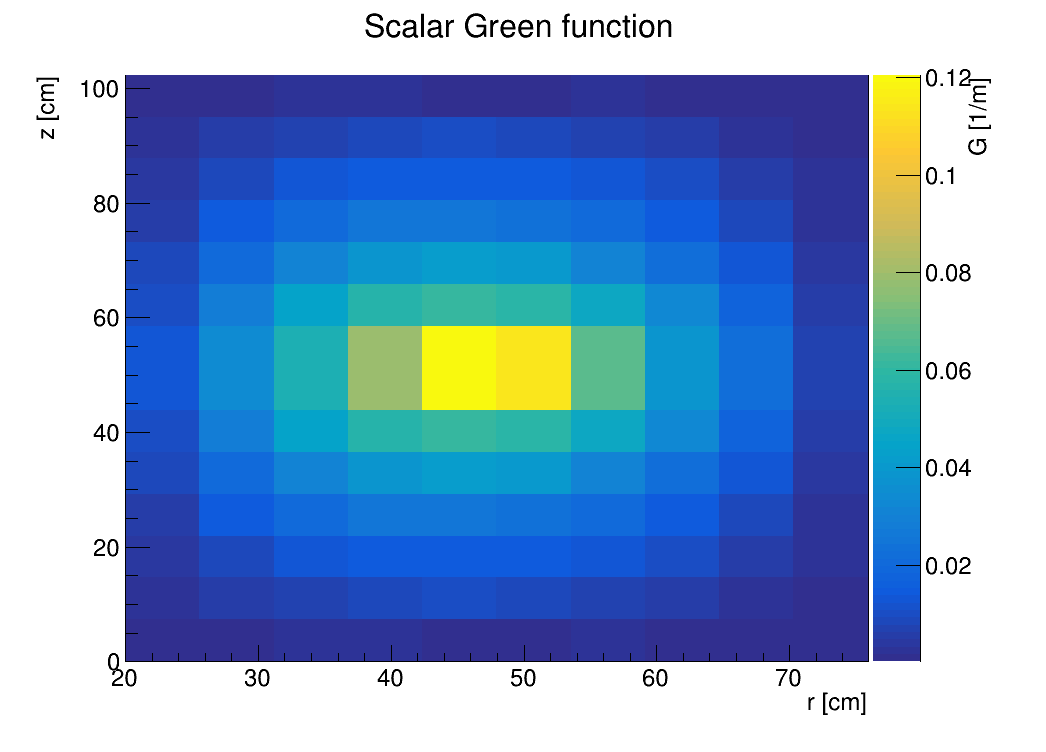

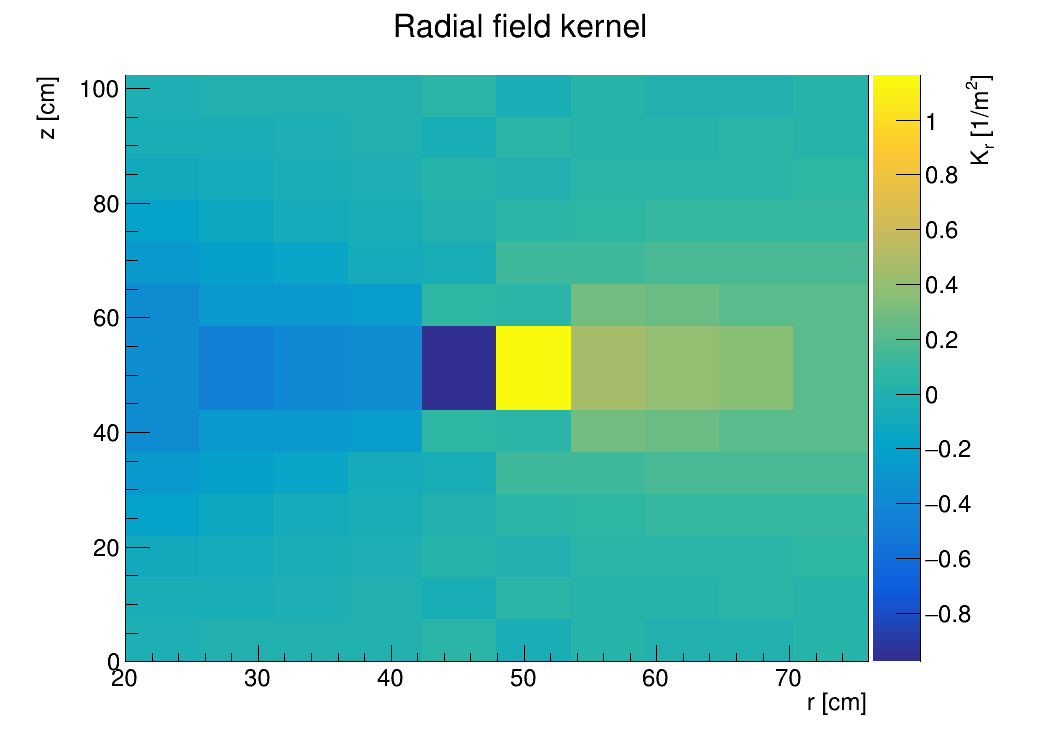

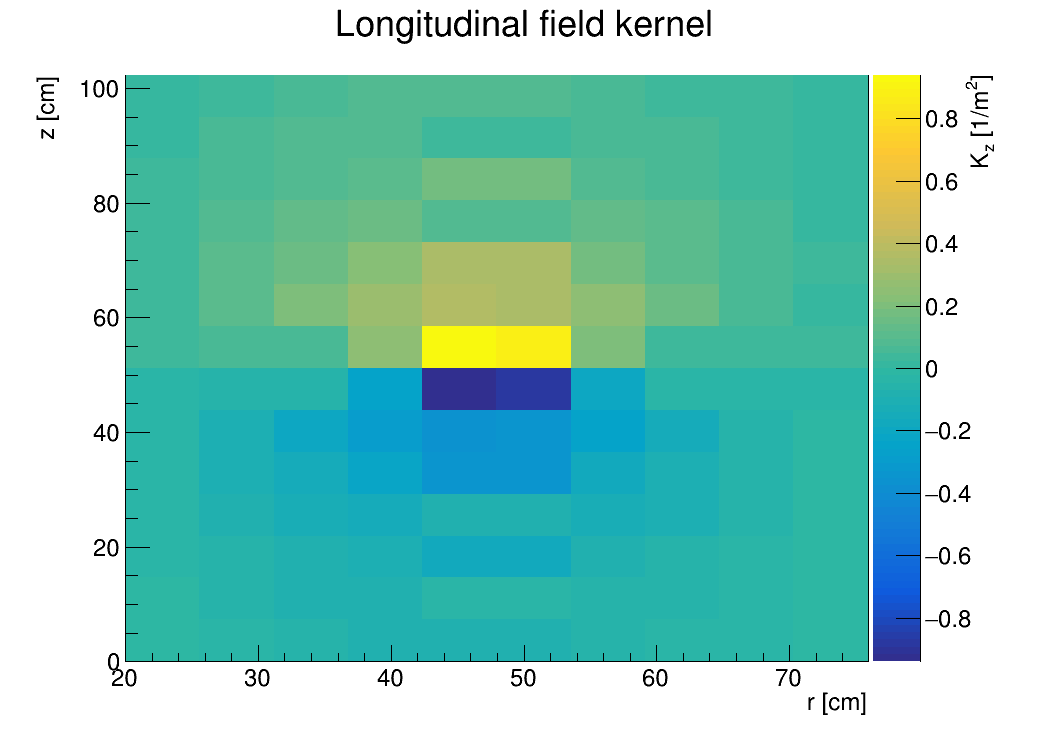

In [7]:
qa_objects=[]; qa_canvases=[]
def make_th2(name,title,v,xe,ye,xt,yt,zt):
    h=root.TH2D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"))
    h.SetDirectory(0); h.GetXaxis().SetTitle(xt); h.GetYaxis().SetTitle(yt); h.GetZaxis().SetTitle(zt)
    for i in range(v.shape[0]):
        for j in range(v.shape[1]): h.SetBinContent(i+1,j+1,float(v[i,j]))
    qa_objects.append(h); return h
def draw(stem,h):
    c=root.TCanvas(stem,"",1050,780); c.SetRightMargin(.17); c.SetLeftMargin(.12); c.SetBottomMargin(.12)
    h.Draw("COLZ"); c.Update()
    fn=QA_DIR/f"{stem}.png"; c.SaveAs(str(fn)); display(Image(filename=str(fn)))
    qa_canvases.append(c)

if DO_QA:
    irs=np.argmin(abs(r_src-.50)); ips=np.argmin(abs(phi_src)); izs=np.argmin(abs(z_src-.54))
    for stem,arr,title,ztitle in [
        ("green_G",G,"Scalar Green function","G [1/m]"),
        ("green_Kr",Kr,"Radial field kernel","K_{r} [1/m^{2}]"),
        ("green_Kz",Kz,"Longitudinal field kernel","K_{z} [1/m^{2}]")
    ]:
        sl=np.mean(arr[:,:,:,irs,ips,izs],axis=1)
        draw(stem,make_th2("h"+stem,title,sl,r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","z [cm]",ztitle))

## 7. Build the charge density

Only after the Green-function QA do we define the source.

The baseline profile is

$$
\rho(r',\phi',z')
\propto
\frac{1}{r'^\alpha}
\left[
1
+
A_1\cos(\phi'-\phi_1)
+
A_{12}\cos 12(\phi'-\phi_{12})
\right].
$$

The default amplitudes are zero, so the source is axisymmetric.

The density is normalized to the requested volume-weighted mean.

In [8]:
R3=r_src[:,None,None]; P3=phi_src[None,:,None]
raw=(rs0/R3)**RADIAL_POWER_ALPHA * (
    1+M1_AMPLITUDE*np.cos(P3-M1_PHASE)
    +M12_AMPLITUDE*np.cos(12*(P3-M12_PHASE))
) * np.ones((1,1,NZ_SRC))

if np.min(raw)<0: raise ValueError("negative rho")
target=K_EFF*RHO_REFERENCE_NC_PER_M3*1e-9
rho=target*raw/(np.sum(raw*dV)/np.sum(dV))
charge=rho*dV
print("Q total =",np.sum(charge),"C")

Q total = 3.447425552890448e-08 C


## 8. Direct convolution

The discrete form of the Green-function integral is

$$
\Phi_i
=
\frac{1}{\epsilon_0}
\sum_j G_{ij}\Delta Q_j,
$$

with

$$
\Delta Q_j=\rho_j\Delta V_j.
$$

Likewise,

$$
E_{r,i}
=
\frac{1}{\epsilon_0}
\sum_j K_{r,ij}\Delta Q_j,
$$

and similarly for $E_\phi$ and $E_z$.

The six-dimensional arrays are reshaped into matrices of size

$$
N_{\rm obs}\times N_{\rm src},
$$

and multiplied by the source-charge vector.

In [9]:
qvec=charge.reshape(NSRC)
Phi=(G.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Er=(Kr.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ephi=(Kp.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ez=(Kz.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)

print("max |Phi|",np.max(abs(Phi)))
print("max |Er|",np.max(abs(Er)))
print("max |Ephi|",np.max(abs(Ephi)))
print("max |Ez|",np.max(abs(Ez)))

max |Phi| 86.85271521642443
max |Er| 840.1008439175934
max |Ephi| 0.0
max |Ez| 468.68780061153154


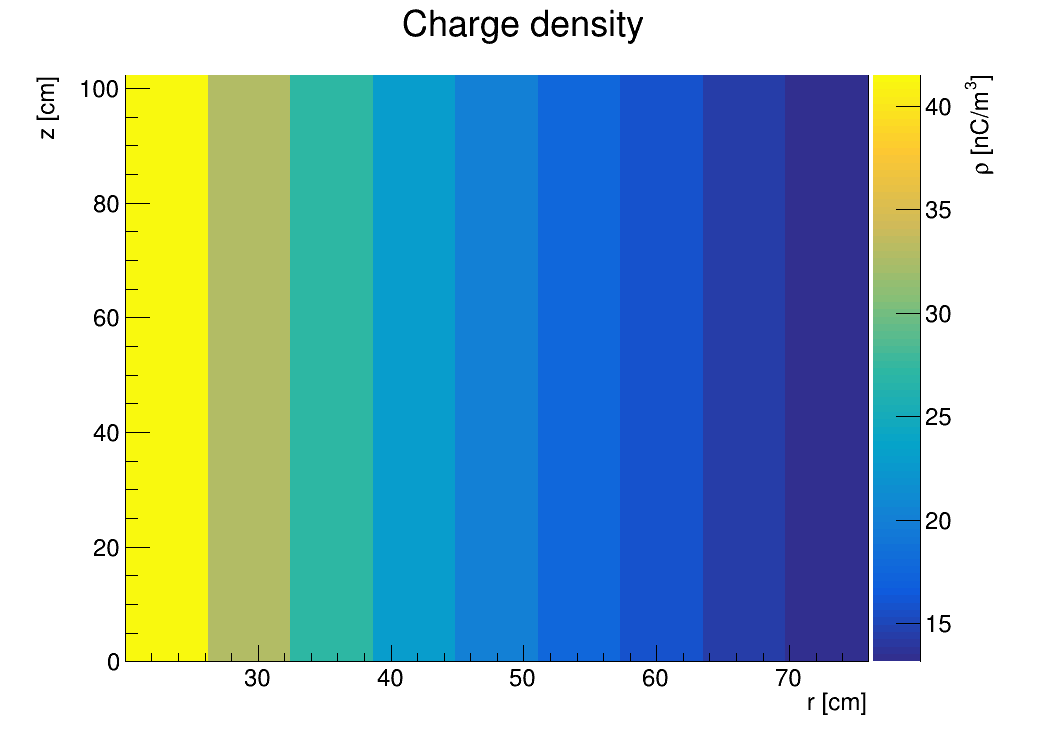

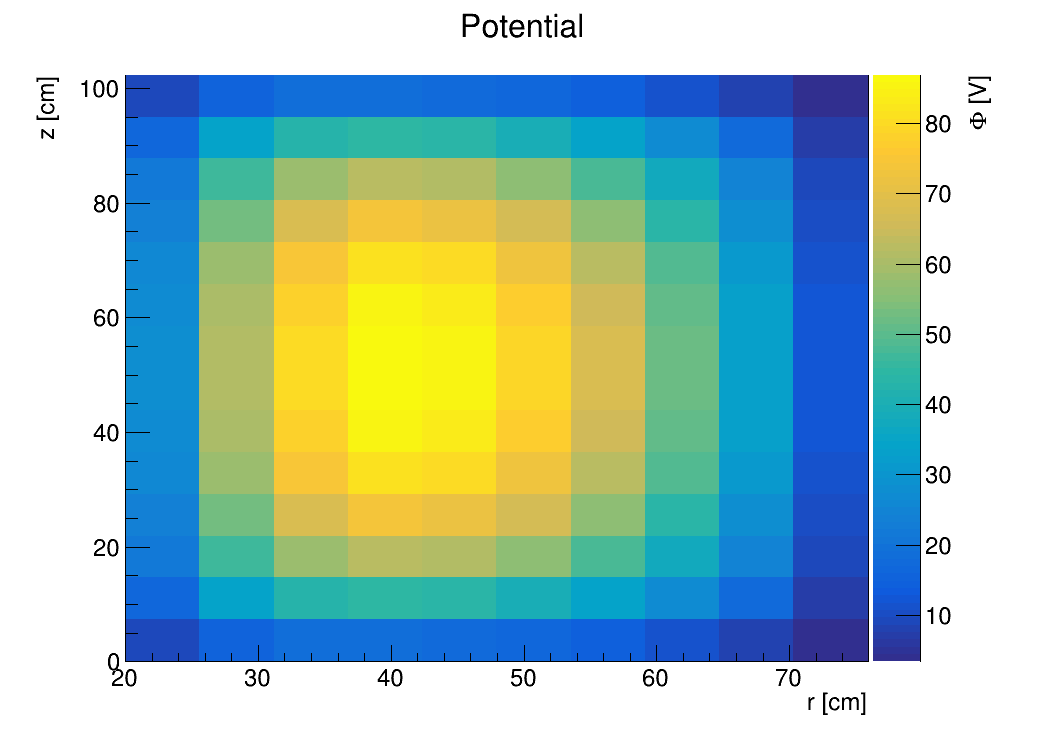

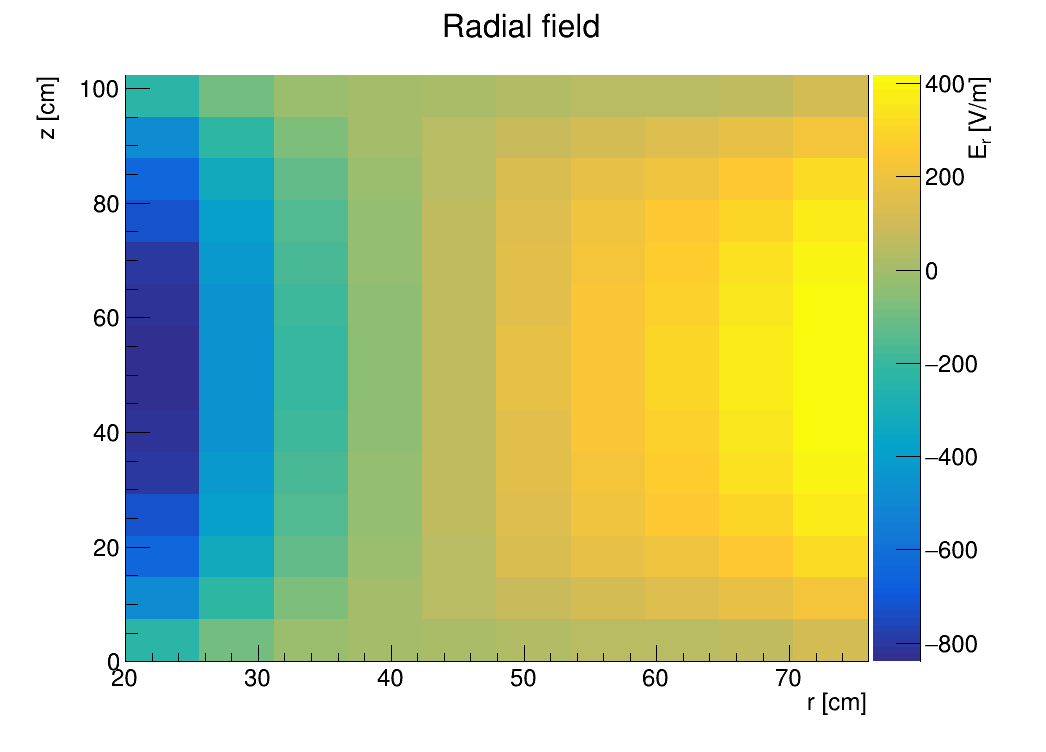

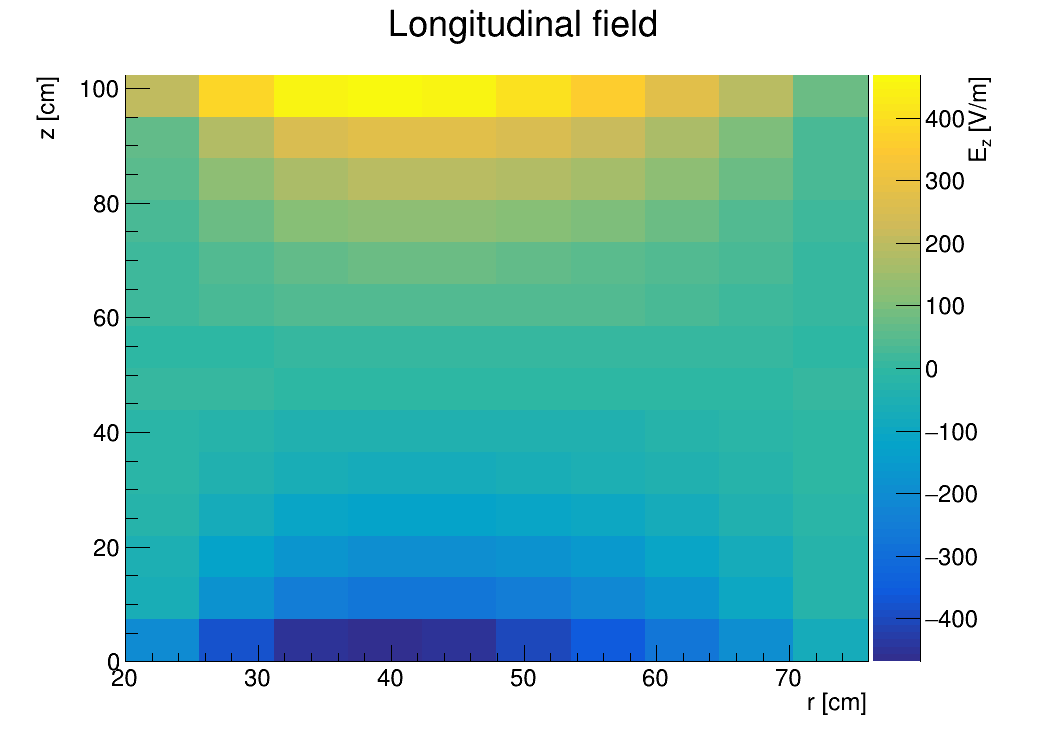

Info in <TCanvas::Print>: png file direct_green_qa/qa_rho.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Phi.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Er.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Ez.png has been created


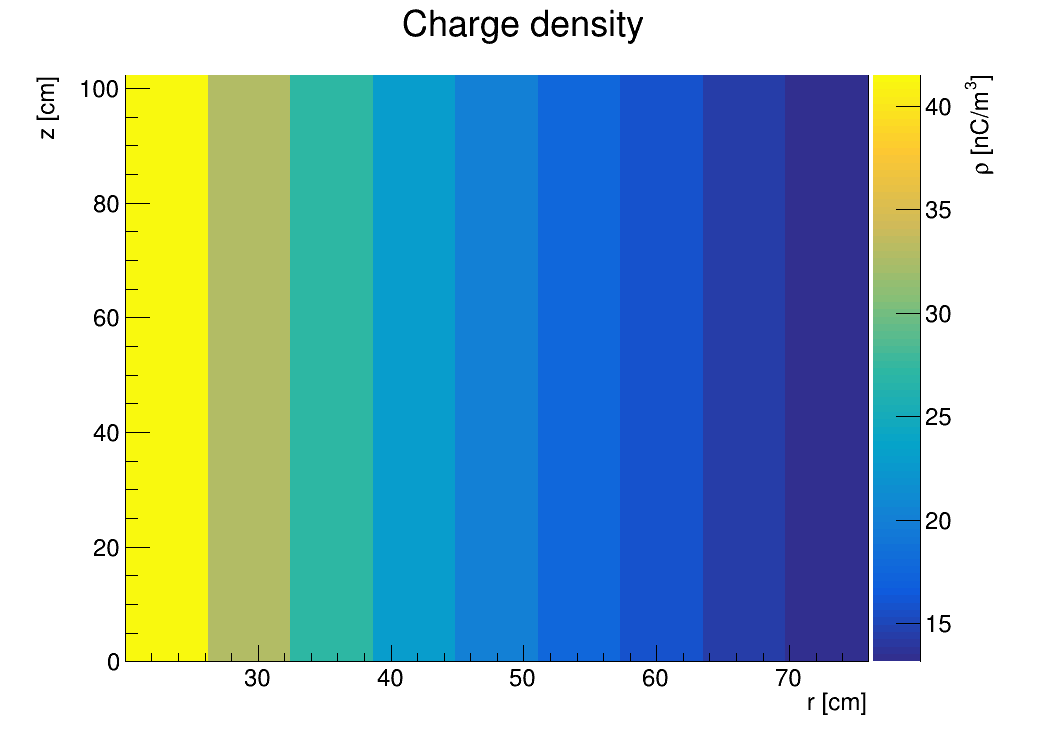

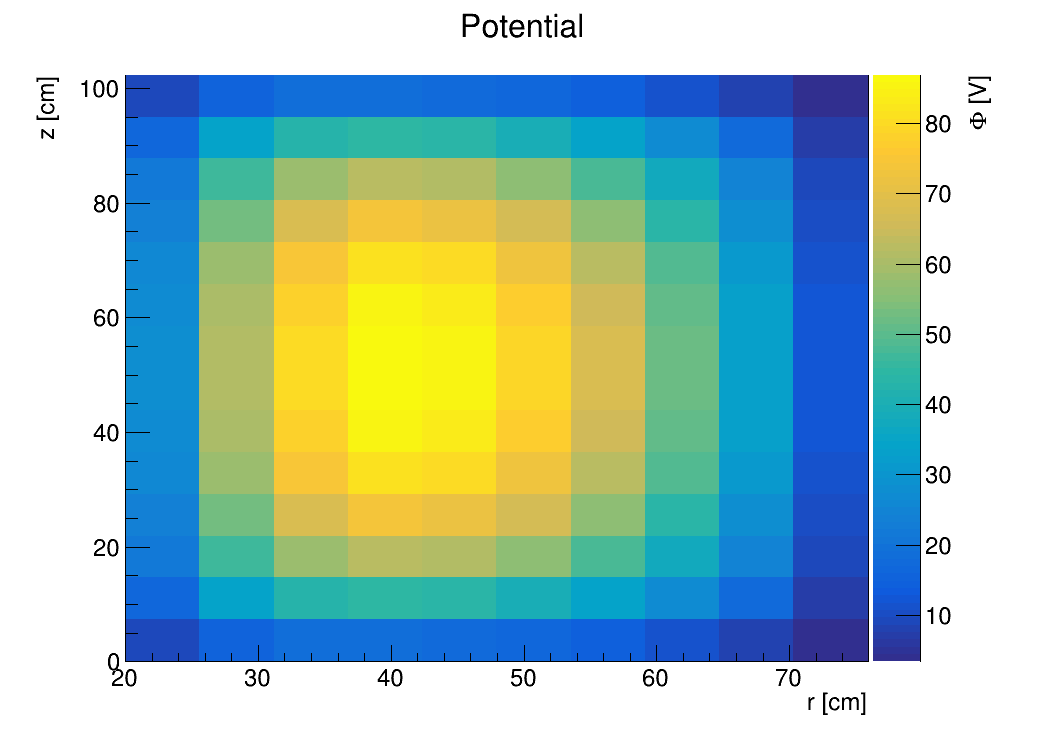

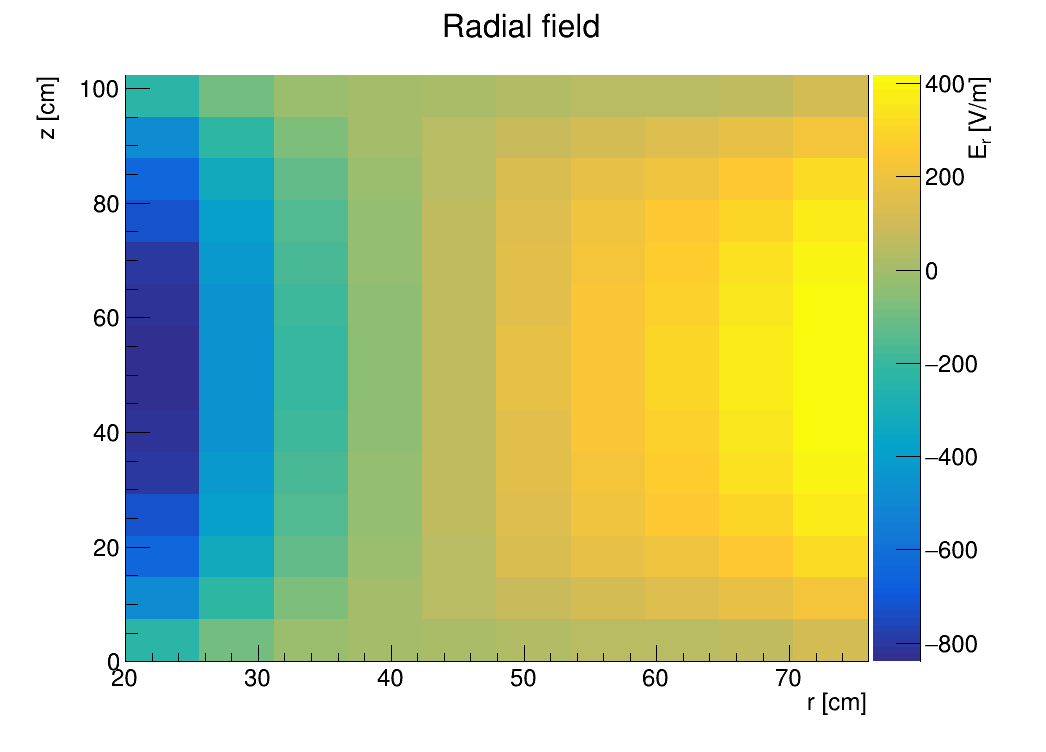

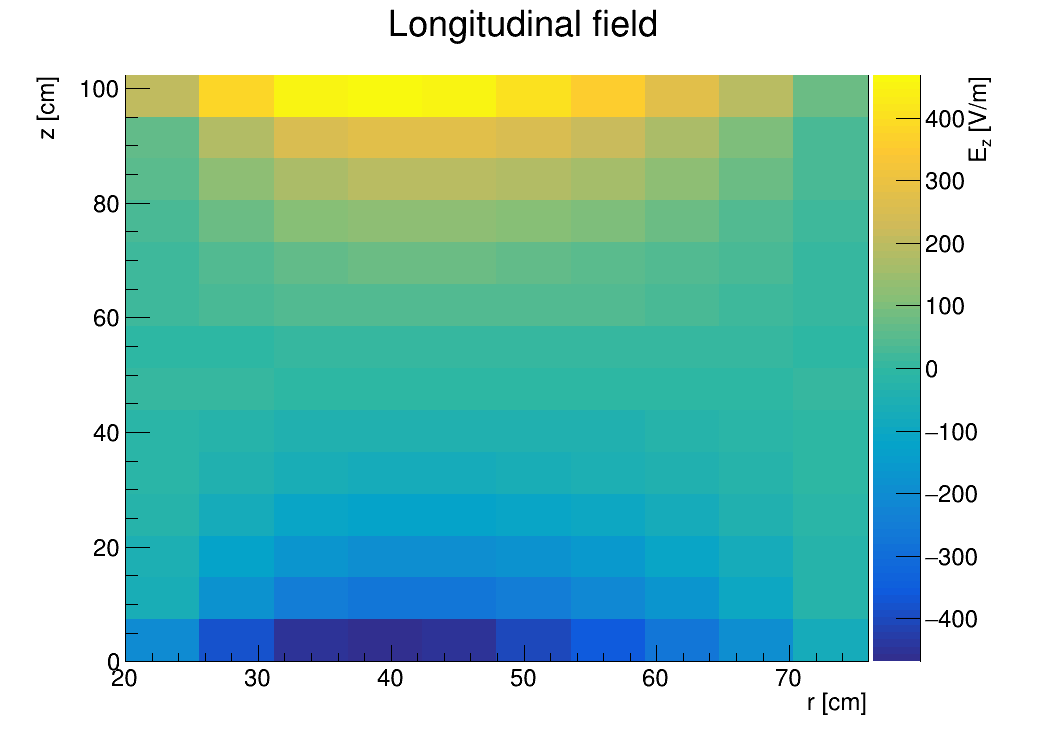

In [10]:
if DO_QA:
    for stem,arr,title,ztitle in [
        ("rho",np.mean(rho,axis=1)*1e9,"Charge density","#rho [nC/m^{3}]"),
        ("Phi",np.mean(Phi,axis=1),"Potential","#Phi [V]"),
        ("Er",np.mean(Er,axis=1),"Radial field","E_{r} [V/m]"),
        ("Ez",np.mean(Ez,axis=1),"Longitudinal field","E_{z} [V/m]")
    ]:
        xe=r_src_edges*M_TO_CM if stem=="rho" else r_obs_edges*M_TO_CM
        ye=z_src_edges*M_TO_CM if stem=="rho" else z_obs_edges*M_TO_CM
        draw("qa_"+stem,make_th2("hqa"+stem,title,arr,xe,ye,"r [cm]","z [cm]",ztitle))

## 9. Output files

The notebook writes three ROOT files.

### Green kernels

```text
sphenix_direct_green_kernels.root
```

The `GreenKernels` tree contains all sampled source-observation pairs and the values of $G$, $K_r$, $K_\phi$, and $K_z$.

### Three-dimensional fields

```text
sphenix_direct_fields_3d.root
```

It contains `hRho`, `hPhi`, `hEr`, `hEphi`, and `hEz`.

### PHGarfield-compatible maps

```text
sphenix_direct_garfield_field.root
```

It contains

```text
QA/hErDefault
QA/hEzDefault
```

with field values in $\mathrm{V/m}$ and axes in centimeters.

In [11]:
# Green kernel TTree
f=root.TFile(GREEN_FILE,"RECREATE")
t=root.TTree("GreenKernels","Direct sampled Green kernels")
idx={n:array("i",[0]) for n in ["iro","ipo","izo","irs","ips","izs"]}
val={n:array("d",[0.]) for n in ["ro","po","zo","rs","ps","zs","G","Kr","Kp","Kz"]}
for n,a0 in idx.items(): t.Branch(n,a0,f"{n}/I")
for n,a0 in val.items(): t.Branch(n,a0,f"{n}/D")
for iro,ro in enumerate(r_obs):
 for ipo,po in enumerate(phi_obs):
  for izo,zo in enumerate(z_obs):
   for irs,rsv in enumerate(r_src):
    for ips,ps in enumerate(phi_src):
     for izs,zs in enumerate(z_src):
      for n,v in zip(idx,[iro,ipo,izo,irs,ips,izs]): idx[n][0]=v
      for n,v in zip(["ro","po","zo","rs","ps","zs"],[ro,po,zo,rsv,ps,zs]): val[n][0]=v
      q=(iro,ipo,izo,irs,ips,izs)
      for n,v in zip(["G","Kr","Kp","Kz"],[G[q],Kr[q],Kp[q],Kz[q]]): val[n][0]=v
      t.Fill()
t.Write()
root.TNamed("metadata_json",json.dumps({"shape":list(G.shape),"used_for_fields":True},indent=2)).Write()
f.Close()

In [12]:
def th3(name,title,v,xe,ye,ze):
    h=root.TH3D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"),len(ze)-1,np.asarray(ze,dtype="d"))
    for i in range(v.shape[0]):
        for j in range(v.shape[1]):
            for k in range(v.shape[2]): h.SetBinContent(i+1,j+1,k+1,float(v[i,j,k]))
    return h

f=root.TFile(FIELD_FILE,"RECREATE")
for h in [
    th3("hRho","rho",rho,r_src_edges*M_TO_CM,phi_src_edges,z_src_edges*M_TO_CM),
    th3("hPhi","Phi",Phi,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEr","Er",Er,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEphi","Ephi",Ephi,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEz","Ez",Ez,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM)
]: h.Write()
f.Close()

f=root.TFile(GARFIELD_FILE,"RECREATE"); d=f.mkdir("QA"); d.cd()
make_th2("hErDefault","Er for PHGarfield",np.mean(Er,axis=1),r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{r} [V/m]").Write()
make_th2("hEzDefault","Ez for PHGarfield",np.mean(Ez,axis=1),r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{z} [V/m]").Write()
f.Close()
print(GREEN_FILE,FIELD_FILE,GARFIELD_FILE)

sphenix_direct_green_kernels.root sphenix_direct_fields_3d.root sphenix_direct_garfield_field.root
